# Plot

In [284]:
import os
import pickle
from pathlib import Path

import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({
    "pdf.fonttype": 42,            # editable text in Adobe Illustrator
    "ps.fonttype": 42,             # editable text in Adobe Illustrator

    "figure.dpi": 200,
    "savefig.dpi": 600,              # very high-res when saving
    "savefig.format": "pdf",         # vector output preferred

    # # Fonts
    # "font.family": "serif",
    # "font.serif": ["Times New Roman"],  # IEEE default

    # font size
    "axes.titlesize": 14,      # subplot title
    "axes.labelsize": 14,      # x/y axis labels
    "xtick.labelsize": 12,     # x tick labels
    "ytick.labelsize": 12,     # y tick labels
    "legend.fontsize": 10,     # legend text
    "figure.titlesize": 14,    # fig.suptitle

    # # Axes
    "axes.linewidth": 1.5,
    # Lines
    "lines.linewidth": 2.0,
})


# # # G1 29dof
# DATA_ROOT = Path(os.path.realpath('__file__')).parent.parent.parent.parent / "logs" / "rsl_rl/g1_29dof_soft_adaptation"
# # data_dir = DATA_ROOT / "2026-03-24_19-30-46" / "logs"
# data_dir = DATA_ROOT / "2026-03-25_01-08-38" / "logs"

# DATA_ROOT = Path(os.path.realpath('__file__')).parent.parent.parent.parent / "logs" / "rsl_rl/g1_29dof_soft_adaptation_finetune"
# # data_dir = DATA_ROOT / "2026-03-27_12-29-39" / "logs"
# data_dir = DATA_ROOT / "2026-03-28_16-20-16" / "logs"

# teacher
DATA_ROOT = Path(os.path.realpath('__file__')).parent.parent.parent.parent / "logs" / "rsl_rl/g1_29dof_soft_adaptation"
data_dir = DATA_ROOT / "2026-04-04_18-25-14" / "logs"

In [255]:
def quat_to_yaw(quat):
    """Extract yaw from quaternion [w, x, y, z]"""
    w, x, y, z = quat[..., 0], quat[..., 1], quat[..., 2], quat[..., 3]
    yaw = np.arctan2(2.0*(w*z + x*y), 1.0 - 2.0*(y*y + z*z))
    return yaw

In [256]:
base_pos = slice(0, 3)
yaw_quat_idx = slice(3, 7)  # w, x, y, z
base_lin_vel_idx = slice(7, 10)   # x, y, z
base_ang_vel_idx = slice(10, 13)   # roll, pitch, yaw
velocity_commands_idx = slice(13, 16)  # x, y, yaw
heading_commands_idx = slice(16, 20)


# privileged
priv_base_lin_vel_idx = slice(0, 3)
foot_height_idx = slice(3, 5)

rigid_contact_idx = slice(5, 7)
rigid_contact_force_idx = slice(7, 13)
rigid_air_time_idx = slice(13, 15)

soft_contact_idx = slice(15, 17)
soft_contact_force_idx = slice(17, 23)
soft_air_time_idx = slice(23, 25)

material_idx = slice(25, 28)

# log privileged
contact_idx = slice(5, 7)
contact_force_idx = slice(7, 13)
foot_air_time_idx = slice(13, 15)
material_prop_idx = slice(15, None)

In [305]:
# data_path = data_dir / "rl_play"
# data_path = data_dir / "rl_play_test_01"
# data_path = data_dir / "rl_play_test_02"
# data_path = data_dir / "rl_play_test_03"
# data_path = data_dir / "rl_play_test_04"
data_path = data_dir / "rl_play_test_05"

policy_obs_path = (data_path / "obs/obs.pkl").as_posix()
privileged_obs_path = (data_path / "privileged/privileged.pkl").as_posix()
latent_path = (data_path / "latent/latent.pkl").as_posix()

with open(policy_obs_path, "rb") as f:
    policy_obs = pickle.load(f)
    policy_obs = np.array(policy_obs).squeeze(0)

with open(privileged_obs_path, "rb") as f:
    privileged_obs = pickle.load(f)
    privileged_obs = np.array(privileged_obs).squeeze(0)

with open(latent_path, "rb") as f:
    latent = pickle.load(f)
    latent = np.array(latent).squeeze(0)

print(f"policy_obs shape: {policy_obs.shape}")
print(f"privileged obs shape: {privileged_obs.shape}")
print(f"latent shape: {latent.shape}")

data = {}
data["yaw_quat"] = policy_obs[:, :, yaw_quat_idx]
data["base_lin_vel"] = policy_obs[:, :, base_lin_vel_idx]
data["base_ang_vel"] = policy_obs[:, :, base_ang_vel_idx]
data["velocity_commands"] = policy_obs[:, :, velocity_commands_idx]
data["heading_commands"] = policy_obs[:, :, heading_commands_idx]

privileged_data = {}
privileged_data["base_lin_vel"] = privileged_obs[:, :, priv_base_lin_vel_idx]
privileged_data["foot_height"] = privileged_obs[:, :, foot_height_idx]
privileged_data["contact"] = privileged_obs[:, :, contact_idx]
privileged_data["contact_force"] = privileged_obs[:, :, contact_force_idx]
privileged_data["foot_air_time"] = privileged_obs[:, :, foot_air_time_idx]
privileged_data["material_prop"] = privileged_obs[:, :, material_prop_idx]

policy_obs shape: (1, 500, 26)
privileged obs shape: (1, 500, 18)
latent shape: (1, 500, 64)


### Plot

### privileged info plot

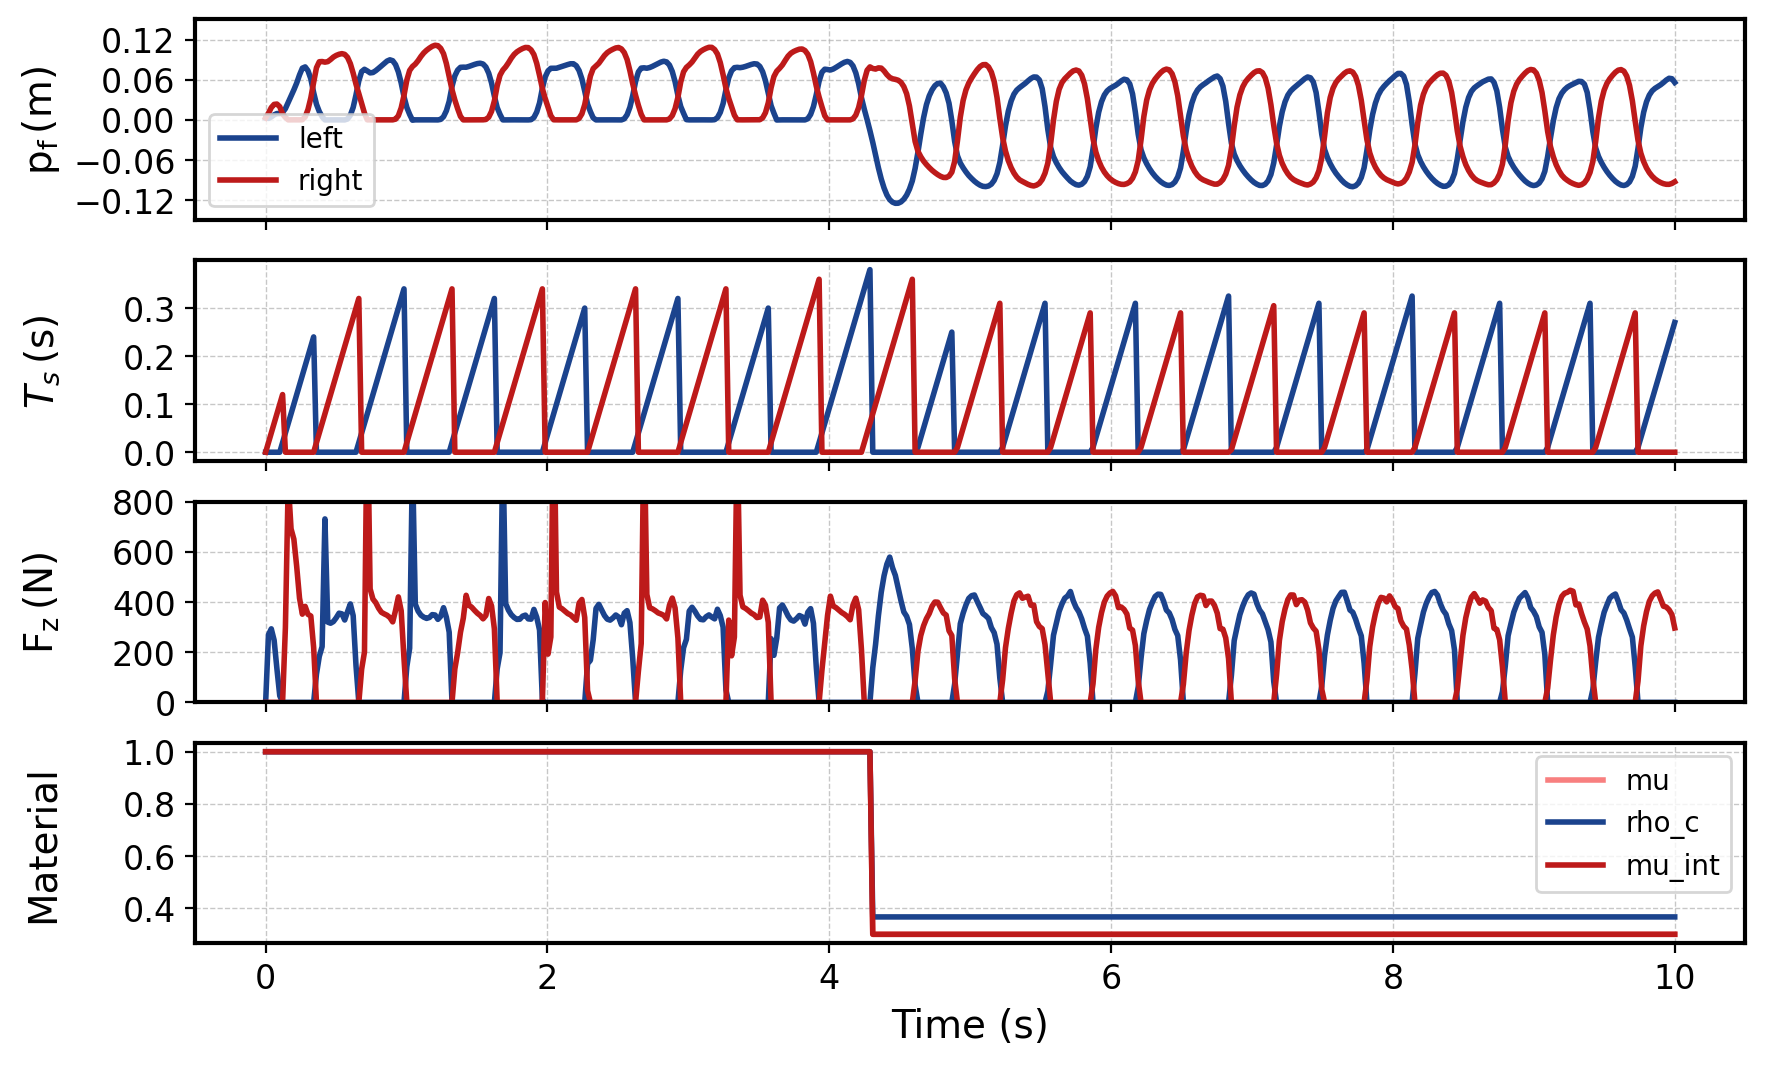

In [310]:
ENV_ID = 0
policy_hz = 50
T_terminal = 10.0
t = np.linspace(0, T_terminal, int(10.0 * policy_hz))
t_range = slice(0, int(10.0 * policy_hz))

colors_left  = ["#1B438D", "#4A87F8"]
colors_right = ["#BD1A1A", "#F87F7F"]

fig, axs = plt.subplots(4, 1, figsize=(10, 6), sharex=True)

def foot_force_norm(force_flat):
    return np.linalg.norm(force_flat.reshape(force_flat.shape[0], 2, 3), axis=-1)

foot_height         = privileged_data["foot_height"][ENV_ID, t_range]
contact       = privileged_data["contact"][ENV_ID, t_range]
# force_norm    = foot_force_norm(log_privileged_data["contact_force"][ENV_ID, t_range])
contact_force    = privileged_data["contact_force"][ENV_ID, t_range][:, [2, 5]]
contact_force = np.expm1(contact_force)

foot_air_time      = privileged_data["foot_air_time"][ENV_ID, t_range]
material_prop = privileged_data["material_prop"][ENV_ID, t_range]


t_plot = t[t_range]

# ── 0: foot height ───────────────────────────────────────────────────────────
ax = axs[0]
ax.plot(t_plot, foot_height[:, 0], label="left",  color=colors_left[0])
ax.plot(t_plot, foot_height[:, 1], label="right", color=colors_right[0])
# ax.plot(t_plot, foot_height.mean(axis=1), label="mean", color="green",
#         linestyle="--", linewidth=1.2)
ax.set_ylabel(r"$\mathrm{p_f} \, \mathrm{(m)}$")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.set_ylim(-0.15, 0.15)
ax.legend(loc="lower left", frameon=True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# ── 1: air time ────────────────────────────────────────────────────────
ax = axs[1]
ax.plot(t_plot, foot_air_time[:, 0], label="left",  color=colors_left[0])
ax.plot(t_plot, foot_air_time[:, 1], label="right", color=colors_right[0])
ax.set_ylabel(r"$T_s \, \mathrm{(s)}$")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
# ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# ── 2: norm of contact force ───────────────────────────────────────────
ax = axs[2]
ax.plot(t_plot, contact_force[:, 0], label="left",  color=colors_left[0])
ax.plot(t_plot, contact_force[:, 1], label="right", color=colors_right[0])
ax.set_ylabel(r"$\mathrm{F_z} \, \mathrm{(N)}$")
ax.set_ylim(0, 800)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
# ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# # ── 3: contact ─────────────────────────────────────────────────────────
# ax = axs[3]
# ax.plot(t_plot, contact[:, 0], label="left",  color=colors_left[0])
# ax.plot(t_plot, contact[:, 1], label="right", color=colors_right[0])
# ax.set_ylabel(r"$\mathrm{c_f}$")
# ax.set_yticks([0, 1])
# # ax.legend(loc="upper right")
# ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


ax = axs[3]
ax.plot(t_plot, material_prop[:, 0], label="mu",  color=colors_right[1])
ax.plot(t_plot, material_prop[:, 1], label="rho_c",  color=colors_left[0])
ax.plot(t_plot, material_prop[:, 2], label="mu_int", color=colors_right[0])
ax.set_ylabel("Material")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.legend(loc="upper right")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


ax.set_xlabel("Time (s)")
fig.align_ylabels(axs)
plt.show()

### latent visualization

#### T-SNE

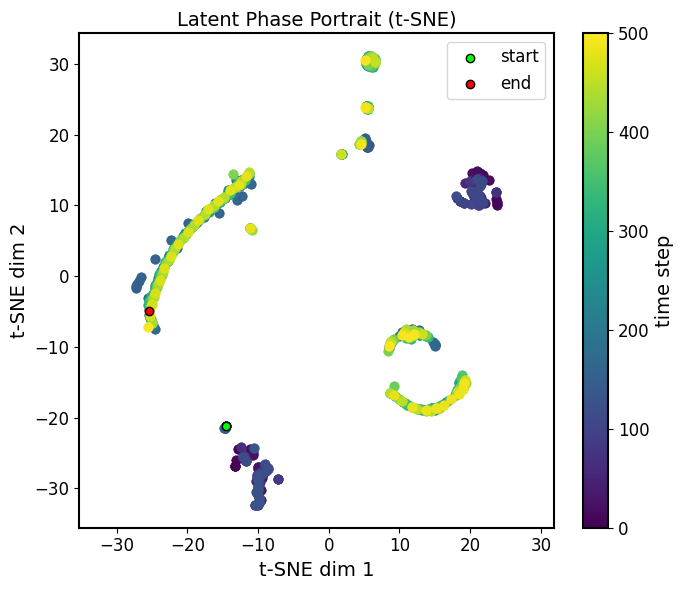

In [259]:
ENV_ID = 0
latent_z = latent[ENV_ID]
mu = latent_z.mean(axis=0, keepdims=True)          # (1, latent_dim)
std = latent_z.std(axis=0, keepdims=True) + 1e-8   # avoid div-by-zero
latent_z = (latent_z - mu) / std
# latent_z = latent_z[300:, :]


import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE

# ── t-SNE: collapse (seq_len, latent_dim) → (seq_len, 2) ─────
tsne = TSNE(
    n_components=2,
    perplexity=min(30, len(latent_z) - 1),
    max_iter=1000,
    random_state=42,
)
z_2d = tsne.fit_transform(latent_z)   # (seq_len, 2)

# ── phase portrait ─────────────────────────────────────────────
seq_len = len(z_2d)
t = np.arange(seq_len)                # time index for coloring

fig, ax = plt.subplots(figsize=(7, 6))

# draw trajectory segments colored by time
for i in range(seq_len - 1):
    color = cm.viridis(t[i] / seq_len)
    ax.scatter(z_2d[i:i+2, 0], z_2d[i:i+2, 1], color=color, lw=1.2, alpha=0.85)

# mark start / end
ax.scatter(*z_2d[0],  c="lime",   zorder=5, label="start", edgecolors="k")
ax.scatter(*z_2d[-1], c="red",    zorder=5, label="end",   edgecolors="k")

sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, seq_len))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="time step")

ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.set_title(f"Latent Phase Portrait (t-SNE)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.axis("equal")
plt.show()

#### Heatmap

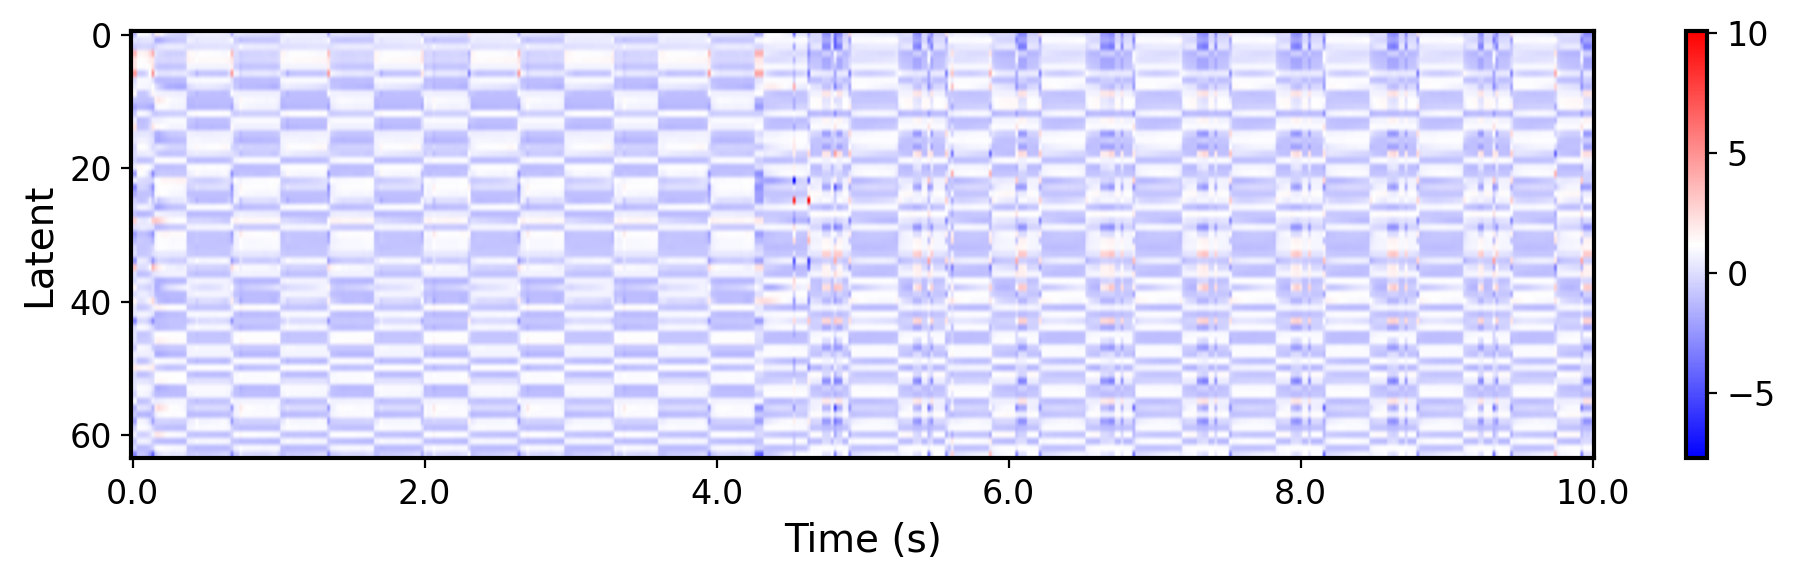

In [307]:
ENV_ID = 0
cmap = "bwr"
latent_z = latent[ENV_ID]
mu = latent_z.mean(axis=0, keepdims=True)
std = latent_z.std(axis=0, keepdims=True) + 1e-8
latent_z = (latent_z - mu) / std

latent_z = latent_z.transpose(1, 0)   # (latent_dim, seq_len)

seq_len = latent_z.shape[1]
t_total = 10.0  # seconds

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(latent_z, aspect="auto", cmap=cmap)
fig.colorbar(im, ax=ax)

# map pixel indices → time in seconds
n_ticks = 6
tick_positions = np.linspace(0, seq_len - 1, n_ticks)
tick_labels = [f"{v:.1f}" for v in np.linspace(0, t_total, n_ticks)]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Latent")
plt.tight_layout()
plt.show()

### joint pos

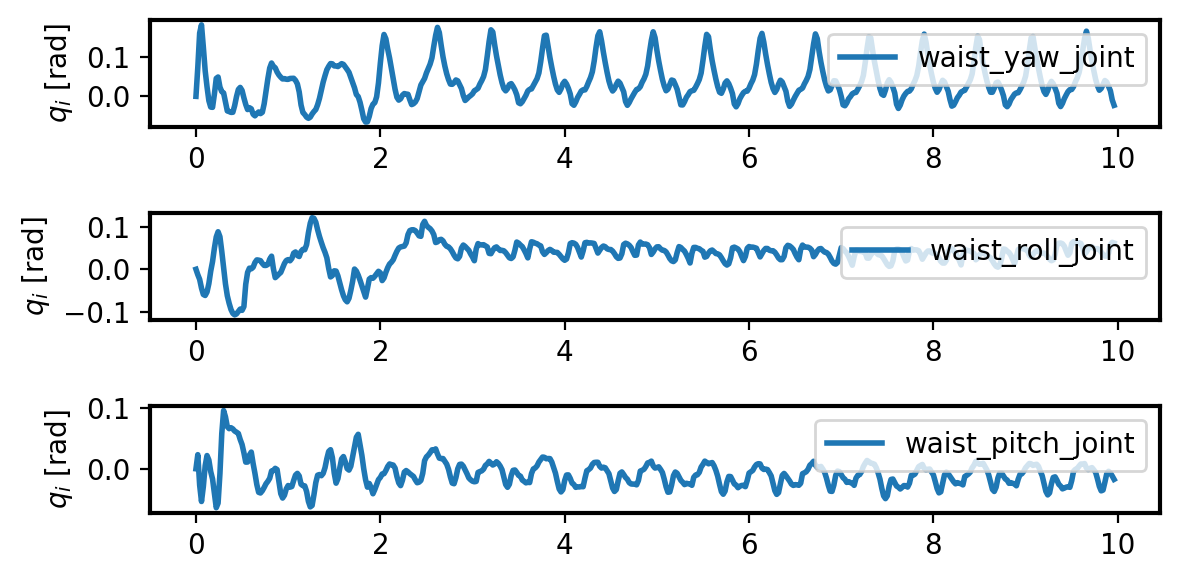

In [ ]:
ENV_ID = np.random.randint(0, data["base_lin_vel"].shape[0])
t = 1/50 * np.arange(0, 1000)
t_range = slice(0, 499)
colors = ["#1B438D", "#3C7FFD", "#BD1A1A"]


fig, axs = plt.subplots(3, 1, figsize=(6, 3))
joint_names = [
    "waist_yaw_joint", 
    "waist_roll_joint", 
    "waist_pitch_joint", 
]

# vx
for i in range(len(joint_names)):
    ax = axs[i]
    ax.plot(t[t_range], data["joint_pos"][ENV_ID, t_range, i], label=joint_names[i])
    ax.legend(loc="upper right")
    ax.set_ylabel(r'$q_i$ [rad]')


fig.tight_layout()
plt.show()

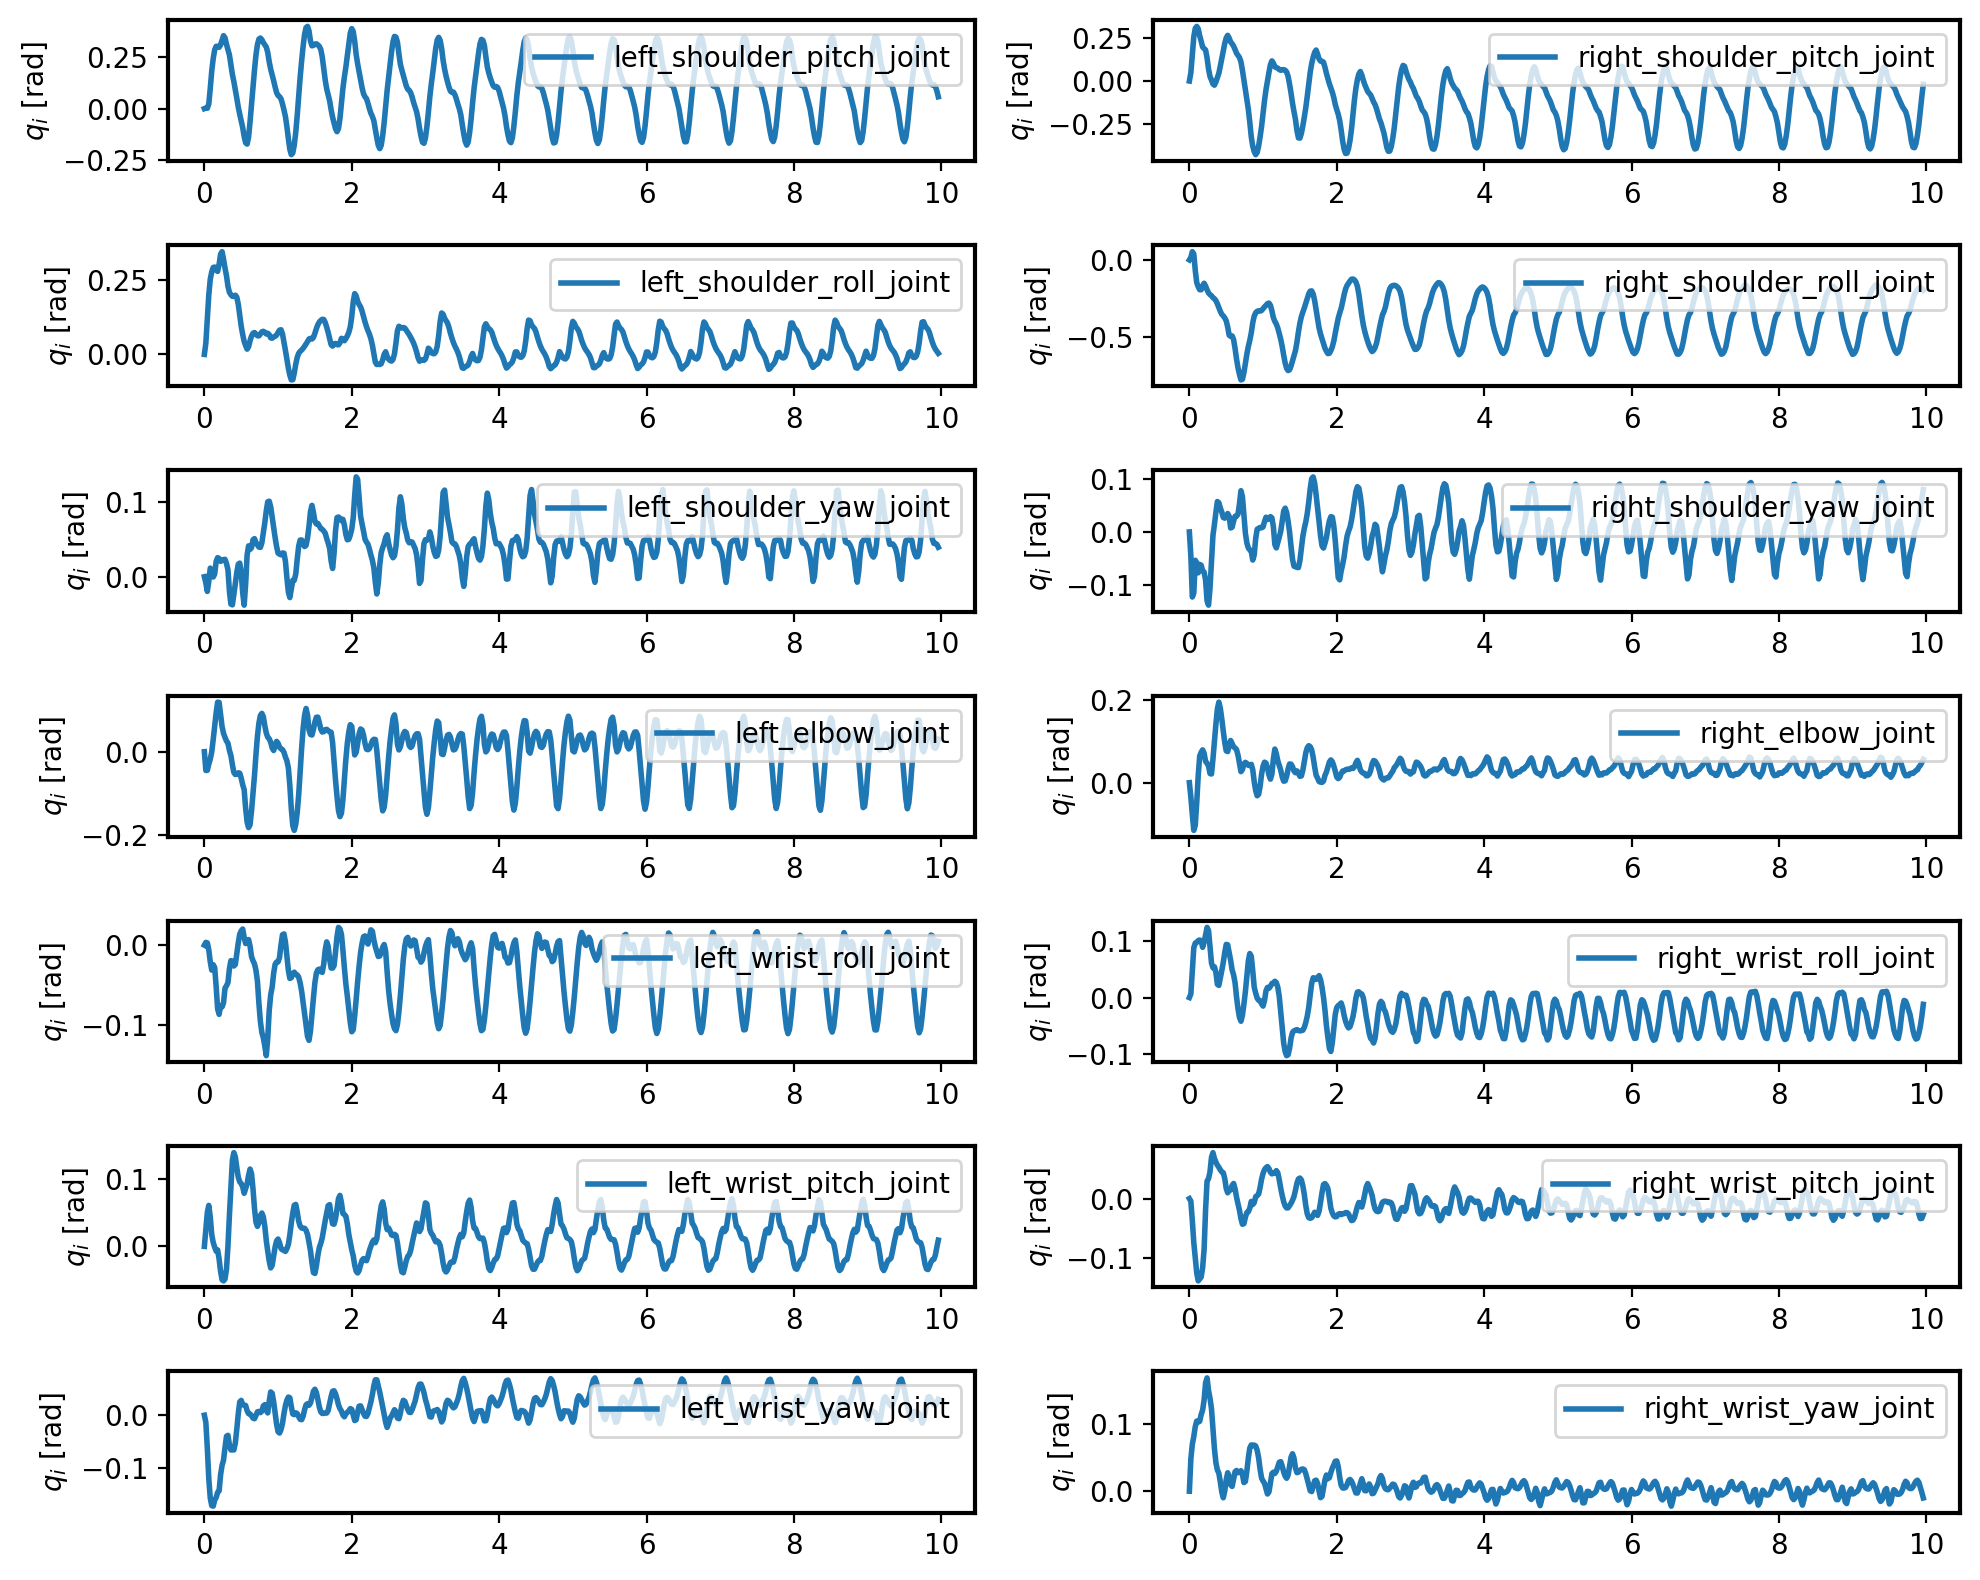

In [ ]:
ENV_ID = np.random.randint(0, data["base_lin_vel"].shape[0])
t = 1/50 * np.arange(0, 1000)
t_range = slice(0, 499)
colors = ["#1B438D", "#3C7FFD", "#BD1A1A"]


fig, axs = plt.subplots(7, 2, figsize=(10, 8))
joint_names = [
    # left arm
    "left_shoulder_pitch_joint", 
    "left_shoulder_roll_joint", 
    "left_shoulder_yaw_joint", 
    "left_elbow_joint", 

    "left_wrist_roll_joint", 
    "left_wrist_pitch_joint", 
    "left_wrist_yaw_joint", 

    # right arm
    "right_shoulder_pitch_joint", 
    "right_shoulder_roll_joint", 
    "right_shoulder_yaw_joint", 
    "right_elbow_joint", 

    "right_wrist_roll_joint", 
    "right_wrist_pitch_joint", 
    "right_wrist_yaw_joint", 
]

# vx
for i in range(len(joint_names)):
    if i < 7:
        ax = axs[i, 0]
    else:
        ax = axs[i - 7, 1]
    ax.plot(t[t_range], data["joint_pos"][ENV_ID, t_range, i+3], label=joint_names[i])
    ax.legend(loc="upper right")
    ax.set_ylabel(r'$q_i$ [rad]')


fig.tight_layout()
plt.show()

### command tracking

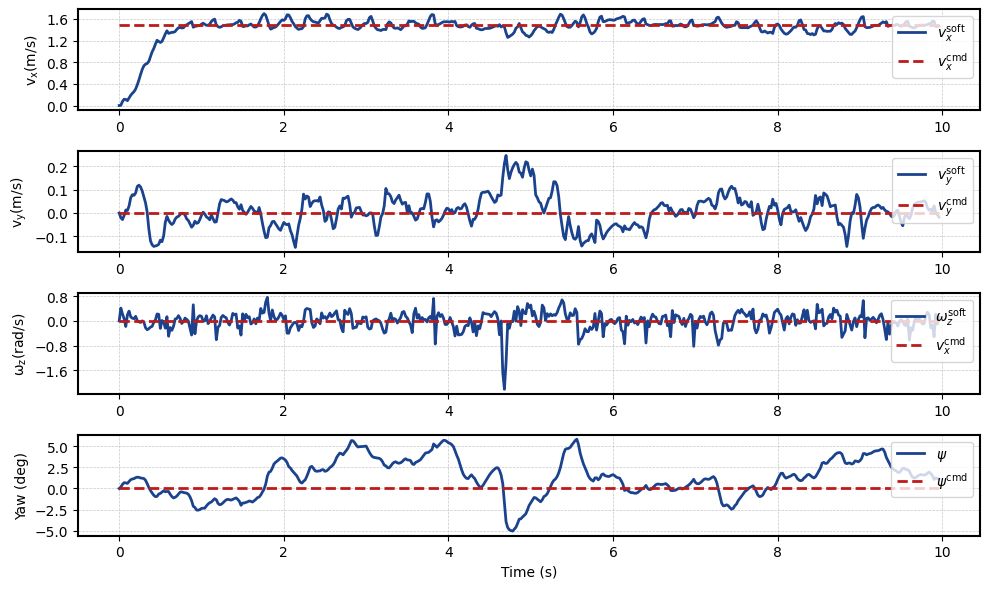

In [8]:
ENV_ID = np.random.randint(0, data["base_lin_vel"].shape[0])
t = 1/50 * np.arange(0, 1000)
t_range = slice(0, 499)
colors = ["#1B438D", "#3C7FFD", "#BD1A1A"]


fig, axs = plt.subplots(4, 1, figsize=(10, 6))

# vx
ax = axs[0]
ax.plot(t[t_range], data["base_lin_vel"][ENV_ID, t_range, 0], label=r"$v_x^\text{soft}$", color=colors[0])
# ax.plot(t[t_range], hard_contact_data["base_lin_vel"][ENV_ID, t_range, 0], label=r"$v_x^\text{hard}$", color=colors[1])
# axs.plot(t[t_range], hard_contact_data["velocity_commands"][ENV_ID, t_range, 0], '--', label=r"$v_x^\text{cmd}$", color="#126D1E")
ax.plot(t[t_range], data["velocity_commands"][ENV_ID, t_range, 0], '--', label=r"$v_x^\text{cmd}$", color=colors[2])
ax.legend(loc="upper right")
# ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$\mathrm{v_x} (\mathrm{m/s})$")
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)


# vy
ax = axs[1]
ax.plot(t[t_range], data["base_lin_vel"][ENV_ID, t_range, 1], label=r"$v_y^\text{soft}$", color=colors[0])
ax.plot(t[t_range], data["velocity_commands"][ENV_ID, t_range, 1], '--', label=r"$v_y^\text{cmd}$", color=colors[2])
# axs.plot(t[t_range], hard_contact_data["base_lin_vel"][ENV_ID, t_range, 1], label=r"$v_y^\text{hard}$", color=colors[0])
# axs.plot(t[t_range], hard_contact_data["velocity_commands"][ENV_ID, t_range, 1], '--', label=r"$v_y^\text{cmd}$", color="#126D1E")
ax.legend(loc="upper right")
# ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$\mathrm{v_y} (\mathrm{m/s})$")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# wz
ax = axs[2]
ax.plot(t[t_range], data["base_ang_vel"][ENV_ID, t_range, 2], label=r"$\omega_z^\text{soft}$", color=colors[0])
ax.plot(t[t_range], data["velocity_commands"][ENV_ID, t_range, 2], '--', label=r"$v_x^\text{cmd}$", color=colors[2])
# ax.plot(t[t_range], hard_contact_data["base_ang_vel"][ENV_ID, t_range, 2], label=r"$\omega_z^\text{hard}$", color=colors[1])
# ax.plot(t[t_range], hard_contact_data["velocity_commands"][ENV_ID, t_range, 2], '--', label=r"$\omega_z^\text{cmd}$", color="#126D1E")
ax.legend(loc="upper right")
# ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$\mathrm{\omega_z} (\mathrm{rad/s})$")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# heading 
ax = axs[3]
heading_yaw = quat_to_yaw(data["yaw_quat"][ENV_ID, t_range])
heading_cmd_yaw = quat_to_yaw(data["heading_commands"][ENV_ID, t_range])
ax.plot(t[t_range], 180/np.pi * np.unwrap(heading_yaw), label=r"$\psi$", color=colors[0])
ax.plot(t[t_range], 180/np.pi * np.unwrap(heading_cmd_yaw), '--', label=r"$\psi^\text{cmd}$", color=colors[2])
ax.legend(loc="upper right")
ax.set_xlabel("Time (s)")
ax.set_ylabel(r"Yaw (deg)")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)


fig.tight_layout()
# plt.savefig("g1_run_sand.pdf")
plt.show()

### velocity tracking statistical result

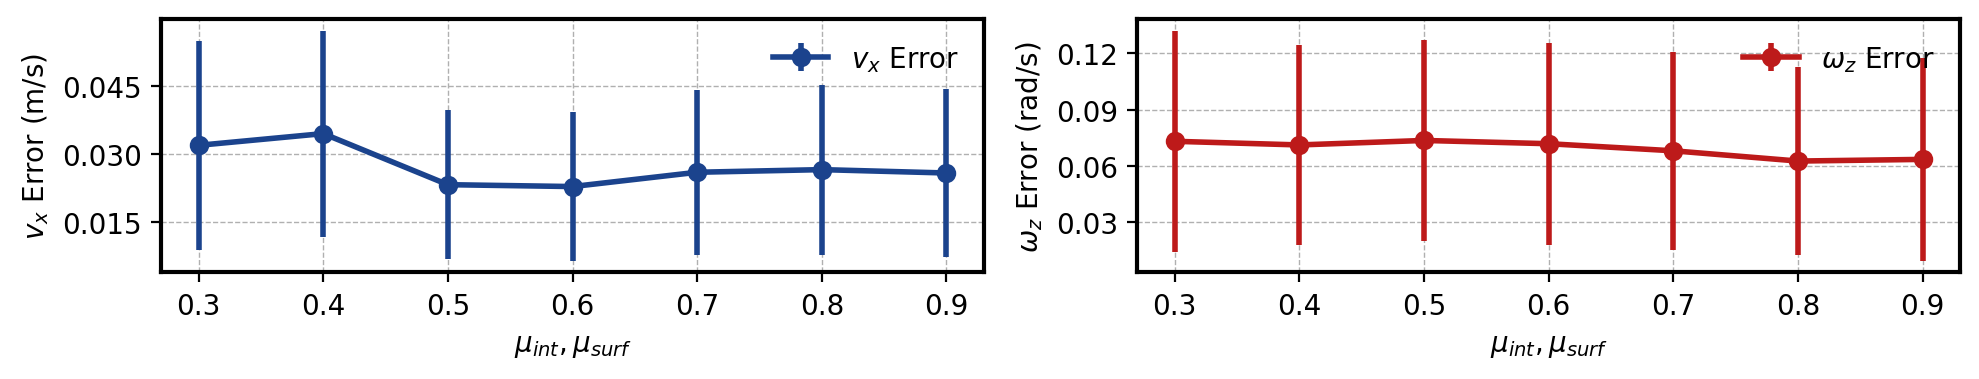

In [61]:
# error_file_path = data_dir / "g1_tracking_error.pkl"
# plot_save_path = "g1_tracking_perf.pdf"

error_file_path = data_dir / "t1_tracking_error.pkl"
plot_save_path = "t1_tracking_perf.pdf"

with open(error_file_path, "rb") as f:
    tracking_error_data = pickle.load(f)

muints = sorted(tracking_error_data.keys())
vx_err_mean = [tracking_error_data[muint]["vx"][0] for muint in muints]
vx_err_std = [tracking_error_data[muint]["vx"][1] for muint in muints]
wz_err_mean = [tracking_error_data[muint]["wz"][0] for muint in muints]
wz_err_std = [tracking_error_data[muint]["wz"][1] for muint in muints]
# mu_range = slice(None)
mu_range = slice(0, -1)

fig, ax = plt.subplots(1, 2, figsize=(10, 2))

# Plot
ax[0].errorbar(muints[mu_range], vx_err_mean[mu_range], yerr=vx_err_std[mu_range],
               fmt='-o', label=r"$v_x$ Error", color="#1B438D")
ax[1].errorbar(muints[mu_range], wz_err_mean[mu_range], yerr=wz_err_std[mu_range],
               fmt='-o', label=r"$\omega_z$ Error", color="#BD1A1A")

# === CREATE CUSTOM LABELS ===
# Convert your numeric keys to sorted floats
tick_positions = sorted(muints[mu_range])

# Build labels: last one becomes "R"
tick_labels = [f"{v:.1f}" for v in tick_positions]
# tick_labels[-1] = "R"

# Apply to both subplots
for a in ax: 
    a.set_xticks(tick_positions)
    a.set_xticklabels(tick_labels)
    a.set_xlabel("$\mu_{int}, \mu_{surf}$")
    a.yaxis.set_major_locator(plt.MaxNLocator(5))
    
ax[0].set_ylabel(r"$v_x$ Error $\mathrm{(m/s)}$")
ax[0].legend(frameon=False)
ax[0].grid(visible=True, which='both', linestyle='--', linewidth=0.5)

ax[1].set_ylabel(r"$\omega_z$ Error $\mathrm{(rad/s)}$")
ax[1].legend(frameon=False)
ax[1].grid(visible=True, which='both', linestyle='--', linewidth=0.5)

fig.tight_layout()
# plt.savefig(plot_save_path)
plt.show()
